# 01 - Exploratory Data Analysis (EDA)

This notebook explores the churn dataset and engineered features used by the production pipeline.

**Prerequisites**:
- Run the ingestion and feature pipelines first, so `features_train.csv` exists:
  - `make ingest`
  - `make features`

We will:
- Inspect the shape and target distribution.
- Look at key feature distributions and relationships.
- Build a bit of intuition for churn drivers that align with the production model.

In [3]:
import sys
import os

# Make sure the project root is on the path
sys.path.insert(0, os.path.abspath('..'))

os.chdir('..')  # run from project root, not notebooks/
print("Working directory:", os.getcwd())

Working directory: f:\Churn


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import EXPORTS_DIR

sns.set_theme(style="whitegrid")
print(f"Using exports directory: {EXPORTS_DIR}")

Using exports directory: F:\Churn\data\exports


In [5]:
# Load training features
features_path = EXPORTS_DIR / "features_train.csv"
features_df = pd.read_csv(features_path)

print(f"Loaded features_train.csv with shape: {features_df.shape}")
features_df.head()

Loaded features_train.csv with shape: (860967, 45)


,msno,is_churn,usage_decay_30d,usage_decay_60d,usage_decay_90d,sessions_last_30d,sessions_last_60d,sessions_last_90d,avg_session_duration_30d,completion_rate_avg_30d,...,days_since_change_point,usage_slope_post_change,pct_usage_change,gender_male_flag,city_encoded,age_bucket_encoded,tenure_days,behavioral_cohort,risk_tier,split
0,qnDJ/kb+B/731fNeyrXdWhSI0GEJeQj9qqtU8Rk1NgY=,0,0.2414,0.0,0.0,27,27,27,1.551000,0.403293,...,999,0.0,0.0,NaN,1,0,40,power_user,high,train
1,qqQtn7MbtxB4U/sT3tlFMNmsN+WIMGuii4VIrXMA0AU=,0,0.0583,0.0,0.0,31,31,31,10.929481,0.968365,...,999,0.0,0.0,1.0,21,4,2498,power_user,low,train
2,owN5S5XjKGaLUTn2r7/xST+R2TOUCrcjFBJbI91/9GA=,0,-0.8785,0.0,0.0,15,15,15,0.763780,0.773480,...,999,0.0,0.0,NaN,1,0,40,regular,low,train
3,+KwrFknYPmALnV+fJFFY+ryUld9HVSJUZRPVZrI8KqA=,0,0.5624,0.0,0.0,31,31,31,0.928403,0.706058,...,999,0.0,0.0,NaN,1,0,1849,power_user,high,train
4,LCx1tl0n2Jg7Cz+FmLW1P3V78e05VH7LvXkyz9Xb52c=,0,-0.2443,0.0,0.0,24,24,24,1.860696,0.816888,...,999,0.0,0.0,1.0,12,3,1657,regular,low,train


Overall churn rate: 9.46%


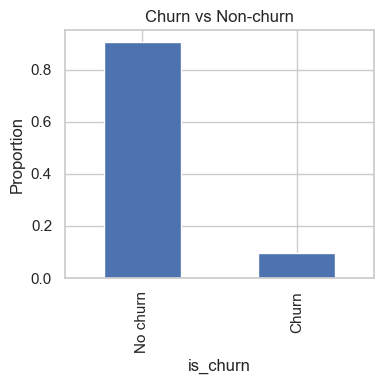

In [6]:
# Target distribution
churn_rate = features_df["is_churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(4, 4))
features_df["is_churn"].value_counts(normalize=True).rename({0: "No churn", 1: "Churn"}).plot.bar(ax=ax)
ax.set_ylabel("Proportion")
ax.set_title("Churn vs Non-churn")
plt.tight_layout()

In [7]:
# Example feature distributions for a few key drivers
num_features = [
    "usage_decay_30d",
    "sessions_last_30d",
    "login_gap_days_avg",
    "ticket_count_90d",
    "payment_failure_count_90d",
]

available = [c for c in num_features if c in features_df.columns]
features_df[available].describe().T

,count,mean,std,min,25%,50%,75%,max
usage_decay_30d,860967.0,-0.123018,0.596253,-2.0,-0.2567,0.00,0.1965,1.0
sessions_last_30d,860967.0,15.718008,10.812804,0.0,5.0000,16.00,26.0000,31.0
login_gap_days_avg,860967.0,2.823133,2.902199,0.0,2.0000,2.43,3.5000,30.0
ticket_count_90d,860967.0,0.072150,0.408628,0.0,0.0000,0.00,0.0000,6.0
payment_failure_count_90d,860967.0,0.004606,0.111583,0.0,0.0000,0.00,0.0000,5.0


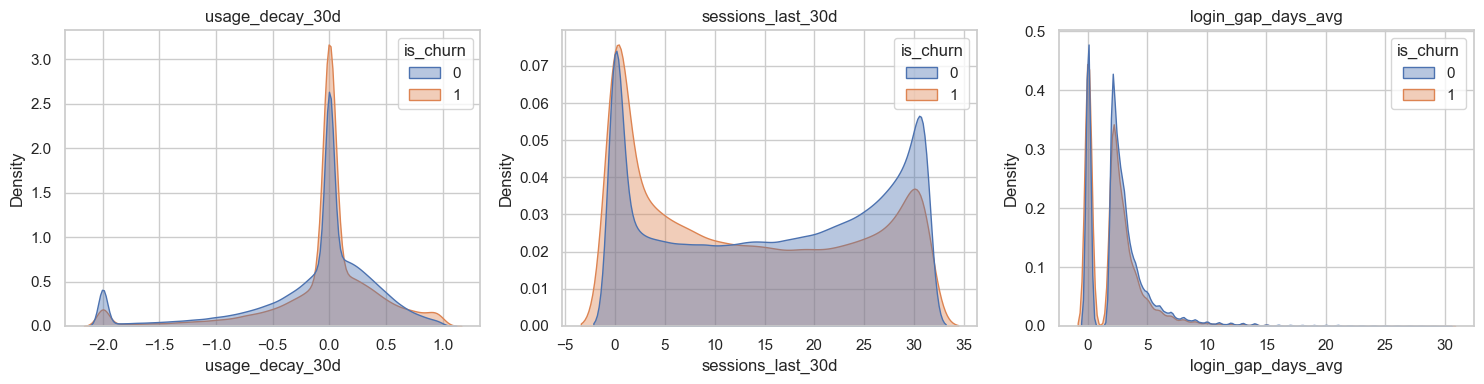

In [8]:
# Churn vs non-churn for selected numeric features
import numpy as np

if available:
    fig, axes = plt.subplots(nrows=1, ncols=min(3, len(available)), figsize=(15, 4))
    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]

    for ax, col in zip(axes, available[:3]):
        sns.kdeplot(
            data=features_df,
            x=col,
            hue="is_churn",
            common_norm=False,
            fill=True,
            alpha=0.4,
            ax=ax,
        )
        ax.set_title(col)

    plt.tight_layout()
else:
    print("No numeric features from the selected list were found in features_train.csv")

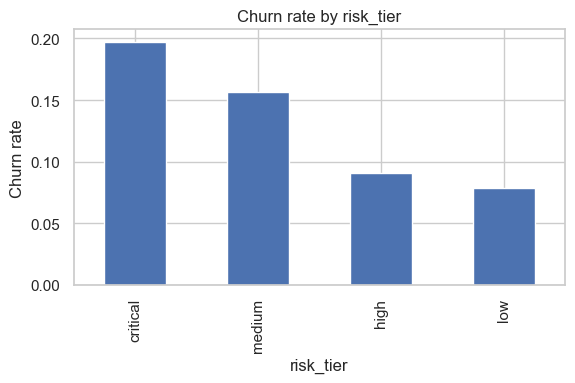

In [9]:
# Relationship between risk_tier (if available) and churn

if "risk_tier" in features_df.columns:
    fig, ax = plt.subplots(figsize=(6, 4))
    tier_churn = (
        features_df.groupby("risk_tier")["is_churn"].mean().sort_values(ascending=False)
    )
    tier_churn.plot.bar(ax=ax)
    ax.set_ylabel("Churn rate")
    ax.set_title("Churn rate by risk_tier")
    plt.tight_layout()
else:
    print("Column 'risk_tier' not found in features_train.csv")